# Two-State Two-Action Mean-Field Control Benchmark

Reference: Meunier, Pham & Reisinger, discrete-space benchmarks, Section "Two-State Two-Action Toy Problem" (`files/reference/discrete_benchmarks.tex`).

**Model.** State space $\mathcal X=\{0,1\}$, action space $\mathcal A=\{\mathrm{ST},\mathrm{MV}\}$. $\mathrm{ST}$ leaves the state unchanged; $\mathrm{MV}$ attempts to switch to the other state and succeeds with probability $\lambda_x$ ($\lambda_0=0.5$, $\lambda_1=0.8$). The transition kernel does not depend on the population law; the mean-field interaction enters only through the reward

$$r(x,\mu) = \mathbf 1_{\{x=1\}} - \mu(1)^2 - \kappa\,|\mu(1)-(1-p)|,\qquad g=r,$$

with $\kappa=10$, $p=0.6$, target law $\bar\mu=(p,1-p)=(0.6,0.4)$, and horizon $T=2$.

**Policy.** A stationary Bernoulli-logit policy $\pi^\theta(\mathrm{MV}\mid x)=\mathrm{sigmoid}(\theta_x)$, shared across the estimators compared below (`mfc.environments.twostate.TwoState.policy_probs`).

**Algorithm.** Simplex-perturbed discrete-state MF-REINFORCE (`mfc.algorithms.simplex`): the population law is randomly perturbed on the simplex, $M_t^{\lambda,\theta}=(1-\lambda)\mu_t^\theta+\lambda q_t$, which makes the mean-field term amenable to a model-free (score-function) gradient estimator. $\lambda$ controls the perturbation scale; a single reusable auxiliary batch estimates the population-flow sensitivities the gradient needs.

**Known optimum.** For these parameters the optimal stationary policy is known in closed form ($\pi^*(\mathrm{ST}\mid 0)=0.2$, $\pi^*(\mathrm{ST}\mid 1)=0.25$), which is what lets every diagnostic below compare the learned policy against ground truth rather than only against itself.

In [1]:
import sys
import time
from pathlib import Path

_notebook_start = time.perf_counter()

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
SRC = ROOT / "src"
for path in (SRC, ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import torch

torch.set_default_dtype(torch.float64)

from configs.twostate import MID, TwoStateRunConfig
from mfc.environments.twostate import TwoState, TwoStateConfig
from mfc.algorithms import simplex
from mfc.plotting import diagnostics as viz
import scripts.train as train_mod
from scripts.train import run_all
from scripts.test import (
    constant_policy_fn,
    generalization_eval,
    gradient_diagnostics,
    group_by,
    load_runs,
    objective_gap,
    perturbation_coverage,
    policy_error,
    population_tracking_error,
    rollout,
    state_distribution,
    theta_diagnostics,
)

## Configuration and budget

This notebook demonstrates the **mid** run tier from `configs/twostate.py`: one seed, the reference's base horizon ($T=2$), full training length (5000 iterations), the exact population flow, and the equal-parameters budget (same $(n_\text{aux},B)=(10,200)$ for every $\lambda$). See `context.md` for why there are three tiers (main/mid/smoke) and `configs/twostate.py`'s docstring for the equal-budget derivation used by `main`.

Two sections below (theta bias/variance across seeds, horizon scaling) need axes `mid` deliberately doesn't sweep (multiple seeds, multiple horizons); those use small labeled supplementary runs instead, to keep this notebook's own runtime modest. Run `scripts/train.py --config main` separately for the full main-tier sweep.

In [2]:
cfg = MID
print(f"algorithms:    {cfg.algorithms}")
print(f"lambdas:       {cfg.lambdas}  (simplex perturbation scale)")
print(f"epsilon:       {cfg.epsilon}  (logit perturbation scale, fixed per context.md)")
print(f"horizons:      {cfg.horizons}")
print(f"seeds:         {cfg.seeds}")
print(f"B={cfg.B}, n_aux={cfg.n_aux}, sigma={cfg.sigma}, lr={cfg.lr}, n_train={cfg.n_train}")
print(f"mu0(1) ~ U([{cfg.mu0_low}, {cfg.mu0_high}]) during training; validation mu0={cfg.mu0_val}")
print(f"budget_modes={cfg.budget_modes}, flows={cfg.flows}")

algorithms:    ('simplex', 'mfreinforce', 'reinforce')
lambdas:       (0.05, 0.1, 0.2, 0.4, 0.8)  (simplex perturbation scale)
epsilon:       0.2  (logit perturbation scale, fixed per context.md)
horizons:      (2,)
seeds:         (0,)
B=200, n_aux=10, sigma=1.0, lr=0.001, n_train=5000
mu0(1) ~ U([0.1, 0.9]) during training; validation mu0=(0.2, 0.8)
budget_modes=('equal_parameters',), flows=('exact',)


## Train (or load cached results)

Loads every saved run under `runs/twostate/mid/`; trains first if none exist yet (`scripts/train.py`'s own entry point — safe to re-run, results are cached to disk).

In [3]:
env = TwoState()
runs_dir = ROOT / "runs" / "twostate" / "mid"
if not list(runs_dir.glob("simplex_*.pt")):
    run_all("twostate", "simplex", "mid")

runs = load_runs("twostate", "simplex", "mid")
total_train_seconds = sum(r["elapsed_seconds"] for r in runs)
print(f"{len(runs)} runs loaded; total training compute time: {total_train_seconds:.1f}s ({total_train_seconds / 60:.1f} min)")
for r in sorted(runs, key=lambda r: r["lam"]):
    print(f"  lambda={r['lam']:<5} seed={r['seed']}  elapsed={r['elapsed_seconds']:.1f}s  final validation J={r['validation_J'][-1].item():.4f}")

5 runs loaded; total training compute time: 394.9s (6.6 min)
  lambda=0.05  seed=0  elapsed=36.4s  final validation J=-5.0798
  lambda=0.1   seed=0  elapsed=67.4s  final validation J=-4.6683
  lambda=0.2   seed=0  elapsed=145.8s  final validation J=-4.0636
  lambda=0.4   seed=0  elapsed=103.8s  final validation J=-4.0363
  lambda=0.8   seed=0  elapsed=41.5s  final validation J=-6.4751


## Ground truth

The closed-form optimal policy and its equivalent $\theta^*$ under this notebook's Bernoulli-logit parametrization (`TwoState.optimal_policy`, `TwoState.optimal_theta`), plus the exact objective at $\theta^*$ — the reference line every plot below compares against.

In [4]:
mu0_val = torch.tensor(MID.mu0_val)
optimal_theta = env.optimal_theta()
optimal_J = simplex.exact_objective(env, env.policy_probs, optimal_theta, mu0_val, MID.horizons[0]).item()

print("optimal policy pi*(a|x):")
print(env.optimal_policy())
print(f"\noptimal theta*: {optimal_theta.tolist()}")
print(f"J(theta*; mu0_val={MID.mu0_val}) = {optimal_J:.4f}")

optimal policy pi*(a|x):
tensor([[0.2000, 0.8000],
        [0.2500, 0.7500]])

optimal theta*: [1.3862943611198908, 1.0986122886681091]
J(theta*; mu0_val=(0.2, 0.8)) = -3.3600


## Evolution of the validation reward

The exact validation objective $J(\theta_m;\mu_0^{val})$ every 10 training iterations, one line per $\lambda$, against the optimal value $J(\theta^*)$.

/home/adonis/Internship/MFC_RL/src/mfc/plotting/diagnostics.py:51: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1879.)
  mean, std = J.mean(dim=0), J.std(dim=0)


Text(0.0, 1.0, 'Validation objective during training')

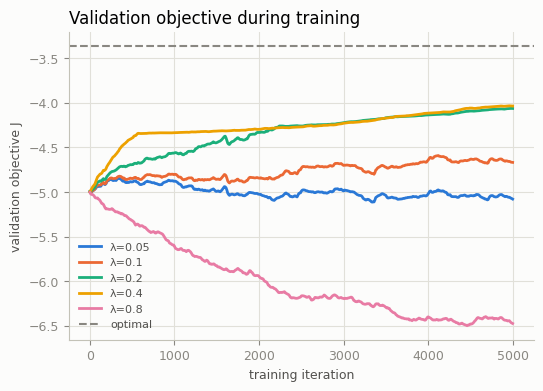

In [5]:
fig, ax = viz.plot_validation_curve(runs, optimal_J=optimal_J)
ax.set_title("Validation objective during training", loc="left")

## State distribution over time

The learned policy's population flow $\mu_t^\theta$ from $\mu_0^{val}$, against the flow under the optimal policy and the target law $\bar\mu$ (dotted). Shown for $\lambda=0.2$, the reference's primary perturbation scale.

Text(0.0, 1.0, 'State distribution (learned, solid; optimal, dashed)')

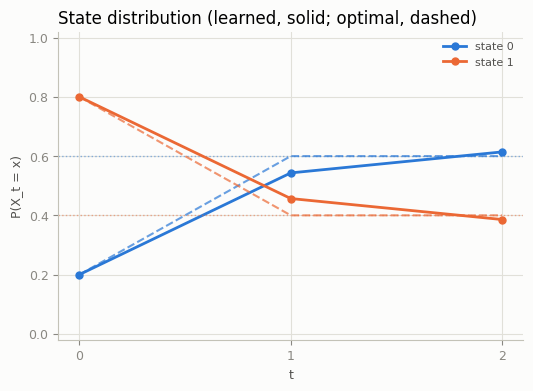

In [6]:
by_lambda = {r["lam"]: r for r in runs}  # mid has one seed per lambda
theta_02 = by_lambda[0.2]["theta_final"]

learned_flow = state_distribution(env, env.policy_probs, theta_02, mu0_val, MID.horizons[0])
optimal_flow = state_distribution(env, constant_policy_fn(env.optimal_policy()), optimal_theta, mu0_val, MID.horizons[0])

fig, ax = viz.plot_state_distribution(learned_flow, target_law=env.target_law, optimal_flow=optimal_flow)
ax.set_title("State distribution (learned, solid; optimal, dashed)", loc="left")

## $J^\lambda$ vs $J$, policy error, and population-tracking error

Three diagnostics across the $\lambda$ sweep, all at each $\lambda$'s own learned $\theta$:
- $J^\lambda$ (Monte Carlo, perturbed) vs $J$ (exact) — the perturbation's effect on the objective itself.
- Policy error $|\pi^\theta(\cdot\mid x)-\pi^*(\cdot\mid x)|$ per state (the reference's $\mathcal E_0,\mathcal E_1$).
- Population-tracking error $\frac1T\sum_t d_{TV}(\mu_t^\theta,\bar\mu)$ (the reference's $\mathcal E_\text{flow}$).

population-tracking error E_flow(theta) per lambda:
  lambda=0.05  E_flow=0.0868
  lambda=0.1   E_flow=0.0661
  lambda=0.2   E_flow=0.0354
  lambda=0.4   E_flow=0.0333
  lambda=0.8   E_flow=0.1563


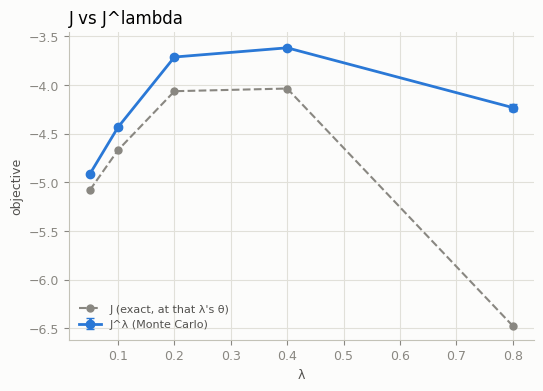

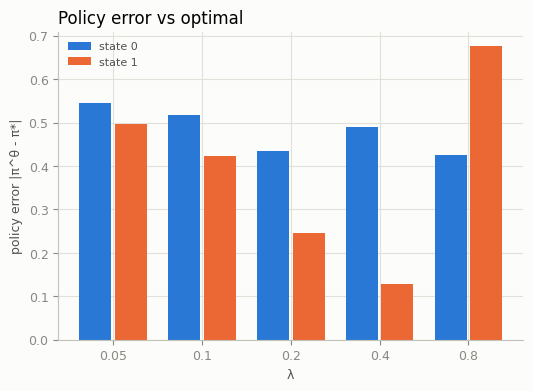

In [7]:
gaps, errors, tracking = {}, {}, {}
for lam, r in by_lambda.items():
    theta = r["theta_final"]
    gaps[lam] = objective_gap(env, env.policy_probs, theta, mu0_val, MID.horizons[0], lam=lam, sigma=MID.sigma, n_samples=5000)
    errors[lam] = policy_error(env, env.policy_probs, theta)
    tracking[lam] = population_tracking_error(env, env.policy_probs, theta, mu0_val, MID.horizons[0]).item()

fig, ax = viz.plot_objective_gap(gaps)
ax.set_title("J vs J^lambda", loc="left")

fig, ax = viz.plot_policy_error(errors)
ax.set_title("Policy error vs optimal", loc="left")

print("population-tracking error E_flow(theta) per lambda:")
for lam in sorted(tracking):
    print(f"  lambda={lam:<5} E_flow={tracking[lam]:.4f}")

## Gradient bias and variance

Empirical bias (vs. the exact unperturbed gradient, via autograd through the differentiable population flow) and variance of the simplex plug-in gradient estimator, at each $\lambda$'s learned $\theta$, from 30 independent re-estimates.

Text(0.0, 1.0, 'Gradient bias (+-1 std)')

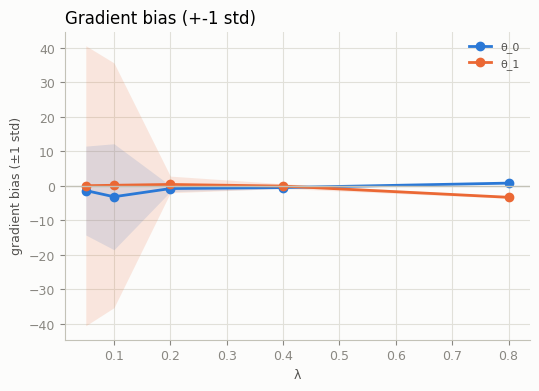

In [8]:
gd_by_lambda = {
    lam: gradient_diagnostics(
        env, env.policy_probs, r["theta_final"], mu0_val, MID.horizons[0],
        lam=lam, n_aux=MID.n_aux, B=MID.B, sigma=MID.sigma, reps=30,
    )
    for lam, r in by_lambda.items()
}
fig, ax = viz.plot_gradient_diagnostics(gd_by_lambda)
ax.set_title("Gradient bias (+-1 std)", loc="left")

## Theta bias and variance across seeds

`mid` trains a single seed per $\lambda$, so seed-to-seed variance isn't visible from it. This section runs a small **supplementary** multi-seed sweep (5 seeds, the same $\lambda$ grid, $T=2$, exact flow, equal parameters, but a shorter 1500-iteration budget so it stays quick) purely to illustrate this diagnostic; the full `main` tier (5 seeds, 10000 iterations) is what should be used for a real bias/variance estimate.

Text(0.0, 1.0, 'Learned theta, mean +- std across 5 seeds')

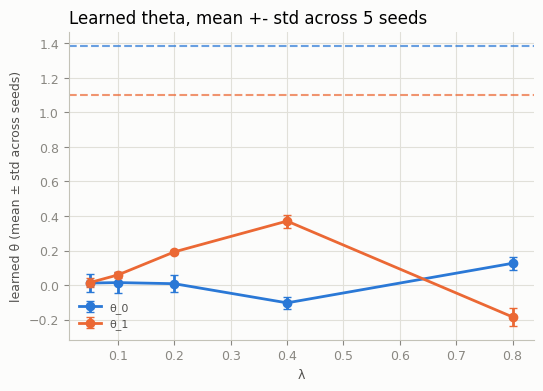

In [9]:
seed_sweep_cfg = TwoStateRunConfig(
    name="notebook_seed_sweep", horizons=(2,), lambdas=MID.lambdas,
    n_train=1500, seeds=(0, 1, 2, 3, 4), flows=("exact",), budget_modes=("equal_parameters",),
)
train_mod.CONFIGS.setdefault("twostate", {})["notebook_seed_sweep"] = seed_sweep_cfg

seed_sweep_dir = ROOT / "runs" / "twostate" / "notebook_seed_sweep"
if not list(seed_sweep_dir.glob("simplex_*.pt")):
    run_all("twostate", "simplex", "notebook_seed_sweep")

seed_sweep_runs = load_runs("twostate", "simplex", "notebook_seed_sweep")
groups = group_by(seed_sweep_runs, "lam")
theta_by_lambda = {lam: theta_diagnostics(torch.stack([r["theta_final"] for r in grp]), optimal_theta) for (lam,), grp in groups.items()}

fig, ax = viz.plot_theta_diagnostics(theta_by_lambda, optimal_theta=optimal_theta)
ax.set_title("Learned theta, mean +- std across 5 seeds", loc="left")

## Simplex-perturbation coverage: $d_{TV}(M^\lambda,\mu)\le\lambda$

The perturbation theorem guarantees $d_{TV}(M_t^{\lambda,\theta},\mu_t^\theta)\le\lambda$ almost surely. Checked here by direct sampling at a few representative population laws.

bound holds for all sampled mu (as guaranteed by the theorem).


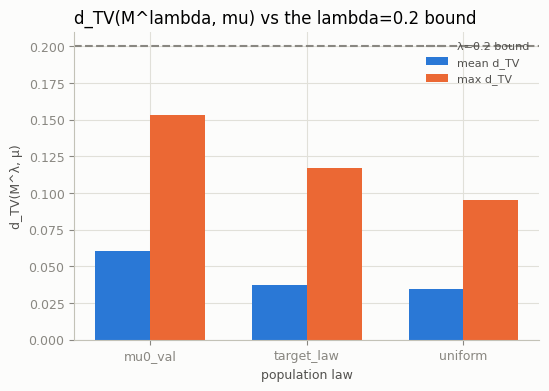

In [10]:
coverage = perturbation_coverage(torch.stack([mu0_val, env.target_law, torch.tensor([0.5, 0.5])]), lam=0.2, sigma=MID.sigma, n_samples=5000)
fig, ax = viz.plot_perturbation_coverage(coverage, lam=0.2, mu_labels=["mu0_val", "target_law", "uniform"])
ax.set_title("d_TV(M^lambda, mu) vs the lambda=0.2 bound", loc="left")

for r in coverage:
    assert r["within_bound"], "the perturbation theorem's bound should never be violated"
print("bound holds for all sampled mu (as guaranteed by the theorem).")

## Learned vs optimal trajectories

One sampled state trajectory under the learned policy ($\lambda=0.2$) and one under the optimal policy, both starting from $\mu_0^{val}$.

Text(0.0, 1.0, 'Sample trajectories')

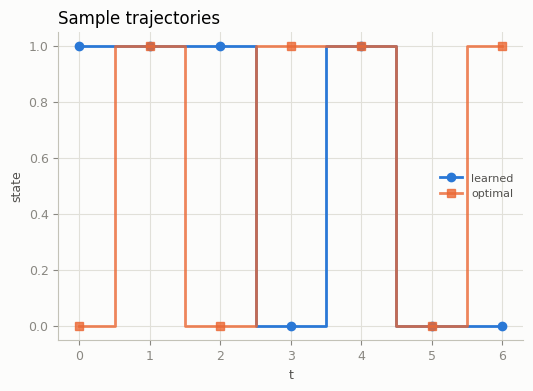

In [11]:
# Independent generators, not a shared `torch.manual_seed` + two sequential
# calls: torch.multinomial's default generator produces markedly
# anti-correlated draws across back-to-back single-sample calls sharing one
# RNG stream (verified separately), which made two sequentially-sampled
# trajectories look like near-exact opposites regardless of the policies.
learned_traj = rollout(env, env.policy_probs, theta_02, mu0_val, T=6, generator=torch.Generator().manual_seed(0))
optimal_traj = rollout(env, constant_policy_fn(env.optimal_policy()), optimal_theta, mu0_val, T=6, generator=torch.Generator().manual_seed(1))
fig, ax = viz.plot_trajectories(learned_traj, optimal_traj)
ax.set_title("Sample trajectories", loc="left")

## Generalization without retraining

Evaluating the $\lambda=0.2$ learned $\theta$ exactly (no retraining) under different initial laws, a longer horizon, a stronger interaction penalty $\kappa$, and misspecified transition rates $\lambda_0,\lambda_1$.

Text(0.0, 1.0, 'J under different scenarios (theta fixed, no retraining)')

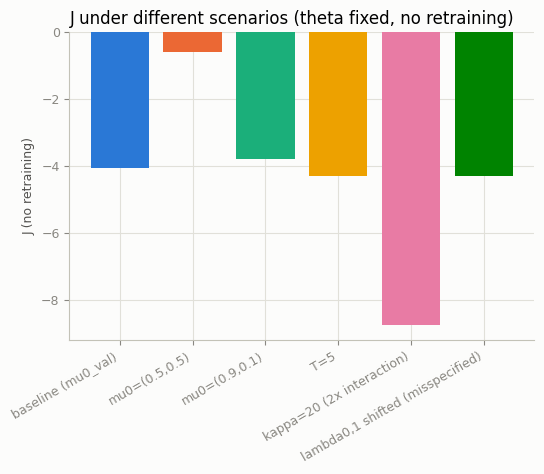

In [12]:
scenarios = [
    {"name": "baseline (mu0_val)"},
    {"name": "mu0=(0.5,0.5)", "mu0": torch.tensor([0.5, 0.5])},
    {"name": "mu0=(0.9,0.1)", "mu0": torch.tensor([0.9, 0.1])},
    {"name": "T=5", "T": 5},
    {"name": "kappa=20 (2x interaction)", "env": TwoState(TwoStateConfig(kappa=20.0))},
    {"name": "lambda0,1 shifted (misspecified)", "env": TwoState(TwoStateConfig(lambda0=0.4, lambda1=0.9))},
]
gen_results = generalization_eval(env, env.policy_probs, theta_02, mu0_val, MID.horizons[0], scenarios)
fig, ax = viz.plot_generalization(gen_results)
ax.set_title("J under different scenarios (theta fixed, no retraining)", loc="left")

## Horizon scaling

Training separately at $T\in\{1,2,5\}$ (small supplementary sweep: 3 seeds, 800 iterations, $\lambda=0.2$) and tracking the final validation objective and the policy error against $T$.

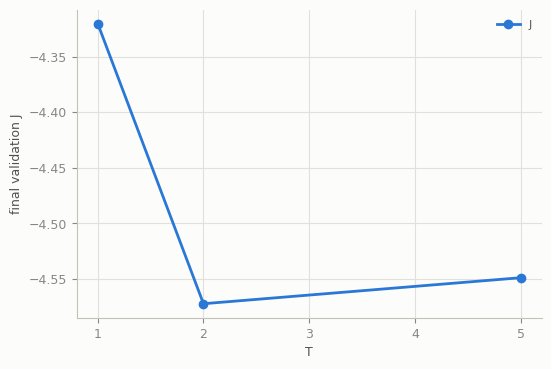

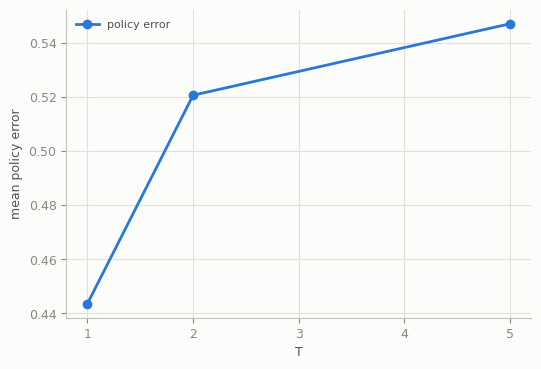

In [13]:
horizon_sweep_cfg = TwoStateRunConfig(
    name="notebook_horizon_sweep", horizons=(1, 2, 5), lambdas=(0.2,),
    n_train=800, seeds=(0, 1, 2), flows=("exact",), budget_modes=("equal_parameters",),
)
train_mod.CONFIGS.setdefault("twostate", {})["notebook_horizon_sweep"] = horizon_sweep_cfg

horizon_sweep_dir = ROOT / "runs" / "twostate" / "notebook_horizon_sweep"
if not list(horizon_sweep_dir.glob("simplex_*.pt")):
    run_all("twostate", "simplex", "notebook_horizon_sweep")

horizon_runs = load_runs("twostate", "simplex", "notebook_horizon_sweep")
by_T = group_by(horizon_runs, "T")
final_J_by_T = {T: torch.stack([r["validation_J"][-1] for r in grp]).mean().item() for (T,), grp in by_T.items()}
policy_err_by_T = {T: torch.stack([policy_error(env, env.policy_probs, r["theta_final"]) for r in grp]).mean().item() for (T,), grp in by_T.items()}

fig, ax = viz.plot_horizon_scaling(final_J_by_T, ylabel="final validation J", label="J")
fig, ax = viz.plot_horizon_scaling(policy_err_by_T, ylabel="mean policy error", label="policy error")

## Missing mean-field term (vs REINFORCE)

`mfc.algorithms.reinforce` computes only the direct policy-score term $L_t\cdot G_t$ against the actual nominal flow, omitting the population-sensitivity correction $Q_t(D_t)$ that accounts for the agent's own influence on the population it is embedded in — see the module docstring for the exact decomposition. This section trains it under the same budget, seeds, and iteration count as the $\lambda=0.2$ simplex run above (the small supplementary multi-seed sweep from the theta bias/variance section) and compares both the validation curves and the distance to the known optimal $\theta^*$.

[twostate/notebook_reinforce_sweep] reinforce_equal_parameters_exact_T2_seed0 ... 

done in 5.8s, final validation J=-9.6660
[twostate/notebook_reinforce_sweep] reinforce_equal_parameters_exact_T2_seed1 ... 

done in 5.4s, final validation J=-9.7302
[twostate/notebook_reinforce_sweep] reinforce_equal_parameters_exact_T2_seed2 ... 

done in 5.4s, final validation J=-9.7473
[twostate/notebook_reinforce_sweep] reinforce_equal_parameters_exact_T2_seed3 ... 

done in 6.1s, final validation J=-9.7567
[twostate/notebook_reinforce_sweep] reinforce_equal_parameters_exact_T2_seed4 ... 

done in 5.8s, final validation J=-9.6645
||theta - theta*||:  simplex   1.650 +- 0.045
                     reinforce 2.352 +- 0.014


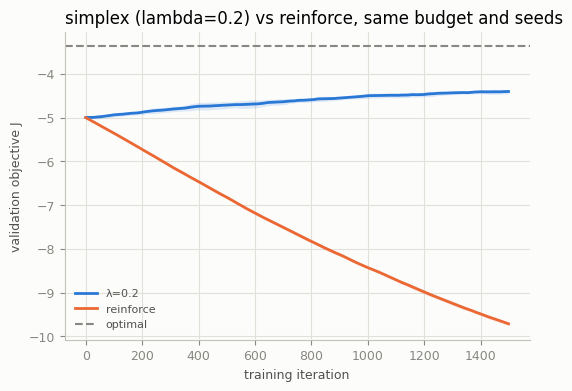

In [14]:
reinforce_sweep_cfg = TwoStateRunConfig(
    name="notebook_reinforce_sweep", horizons=(2,),
    n_train=1500, seeds=(0, 1, 2, 3, 4), flows=("exact",), budget_modes=("equal_parameters",),
)
train_mod.CONFIGS.setdefault("twostate", {})["notebook_reinforce_sweep"] = reinforce_sweep_cfg

reinforce_sweep_dir = ROOT / "runs" / "twostate" / "notebook_reinforce_sweep"
if not list(reinforce_sweep_dir.glob("reinforce_*.pt")):
    run_all("twostate", "reinforce", "notebook_reinforce_sweep")

reinforce_runs = load_runs("twostate", "reinforce", "notebook_reinforce_sweep")
simplex_02_runs = [r for r in seed_sweep_runs if r["lam"] == 0.2]

fig, ax = viz.plot_validation_curve(simplex_02_runs + reinforce_runs, optimal_J=optimal_J)
ax.set_title("simplex (lambda=0.2) vs reinforce, same budget and seeds", loc="left")

simplex_dist = (torch.stack([r["theta_final"] for r in simplex_02_runs]) - optimal_theta).norm(dim=-1)
reinforce_dist = (torch.stack([r["theta_final"] for r in reinforce_runs]) - optimal_theta).norm(dim=-1)
print(f"||theta - theta*||:  simplex   {simplex_dist.mean():.3f} +- {simplex_dist.std():.3f}")
print(f"                     reinforce {reinforce_dist.mean():.3f} +- {reinforce_dist.std():.3f}")

## Summary

Total notebook runtime (including any training performed in this run):

In [15]:
print(f"total notebook runtime: {time.perf_counter() - _notebook_start:.1f}s")

total notebook runtime: 33.3s
